In [119]:
# Basic setup 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [120]:
# Load Dataset
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

<H2>Basic Data Check</H2>

In [121]:
df.shape

(5000, 13)

In [122]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [123]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [124]:
df.duplicated().sum()

np.int64(2)

In [125]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


<H2>EDA</H2>

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

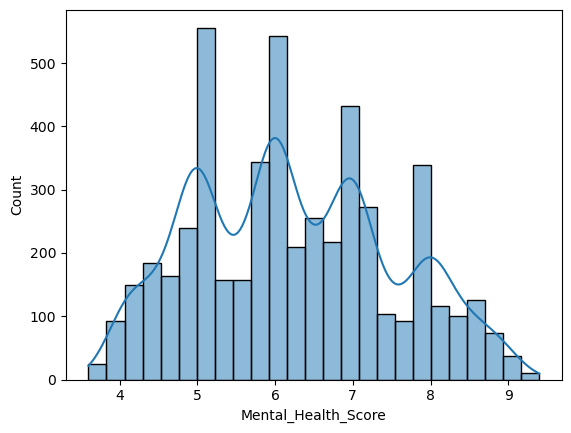

In [127]:
sns.histplot(df["Mental_Health_Score"], kde=True)

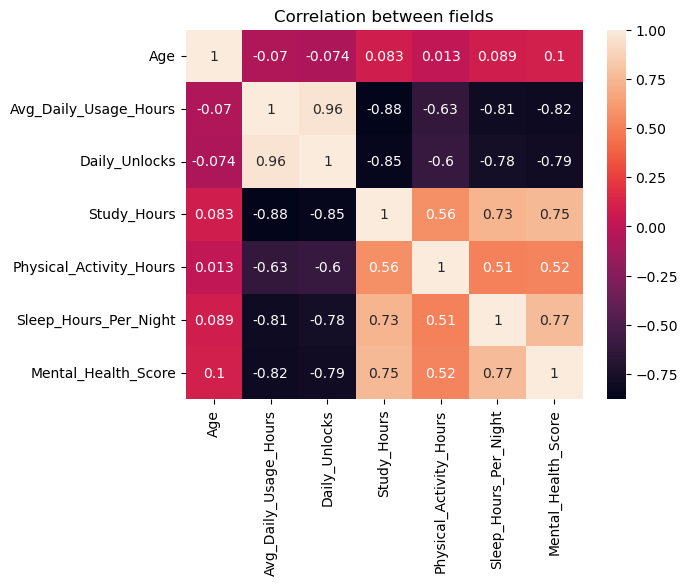

In [128]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation between fields")
plt.show()

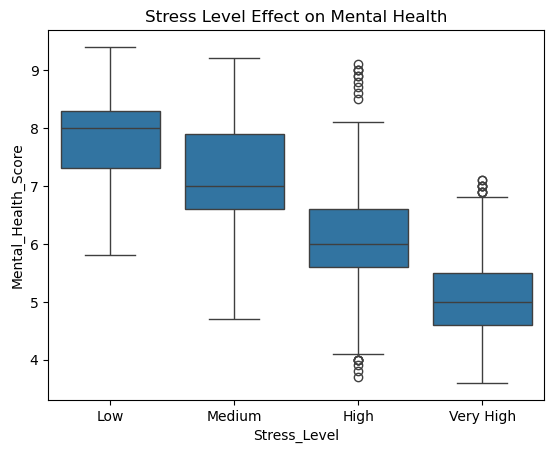

In [129]:
order = ["Low", "Medium", "High", "Very High"]
sns.boxplot(x = df["Stress_Level"], y = df["Mental_Health_Score"], order=order)
plt.title("Stress Level Effect on Mental Health")
plt.show()

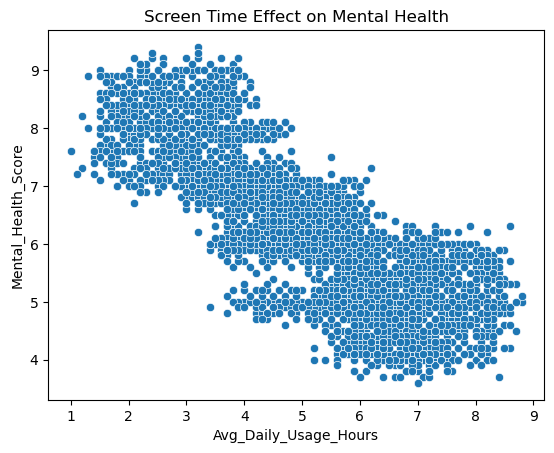

In [130]:
sns.scatterplot(x = df["Avg_Daily_Usage_Hours"], y = df["Mental_Health_Score"])
plt.title("Screen Time Effect on Mental Health")
plt.show()

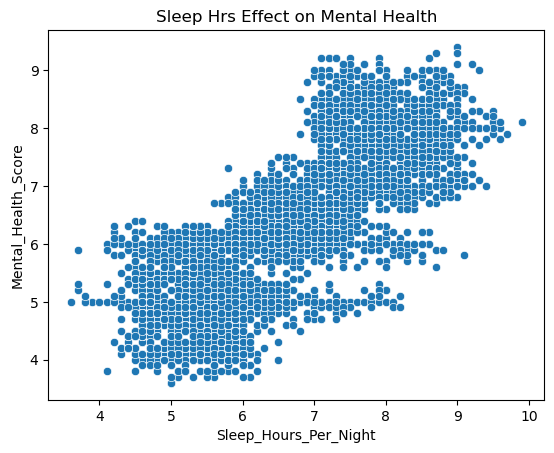

In [131]:
sns.scatterplot(x = df["Sleep_Hours_Per_Night"], y = df["Mental_Health_Score"])
plt.title("Sleep Hrs Effect on Mental Health")
plt.show()

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

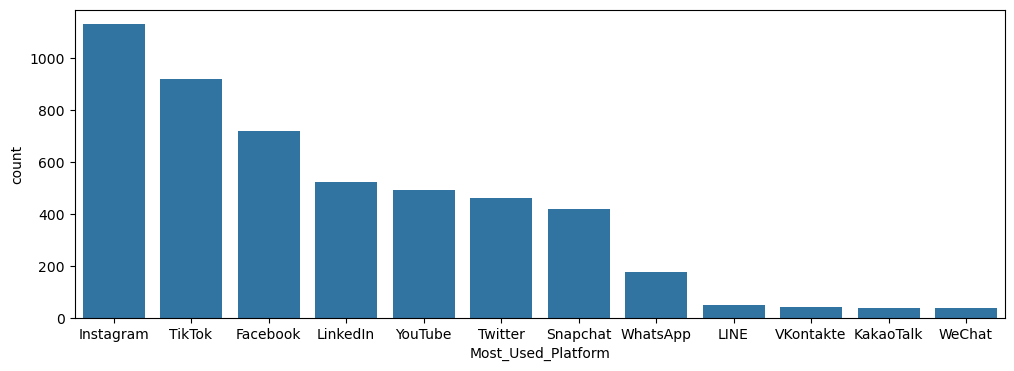

In [132]:
plt.figure(figsize=(12,4))
sns.countplot(x=df["Most_Used_Platform"], order=df["Most_Used_Platform"].value_counts().index)

In [133]:
numFeatures = df.select_dtypes(include="number")
Q1 = numFeatures.quantile(.25)
Q3 = numFeatures.quantile(.75)
IQR = Q3 - Q1
lowerBound = Q1 - 1.5 * IQR
upperBound = Q3 + 1.5 * IQR

outliers = (numFeatures < lowerBound) | (numFeatures > upperBound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


<H2>Data Cleaning</H2>

In [134]:
# Delete/drop duplicates
df = df.drop_duplicates()
# Converting unrealitic or neg value to realistic ones
df["Physical_Activity_Hours"] = df["Physical_Activity_Hours"].clip(lower=0)
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [135]:
topCountries = df["Country"].value_counts().index[:10].tolist()

def groupCountries(country):
    if country in topCountries:
        return country
    else:
        return "Other"

df["Grouped_Country"] = df["Country"].apply(groupCountries)
df.head()


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_Country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [136]:
from sklearn.model_selection import train_test_split


skewedCol = ["Study_Hours"]
otherNumericCol = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks','Physical_Activity_Hours', 'Sleep_Hours_Per_Night',]
ordinalCol = ["Stress_Level"]
normalCol =  ['Gender','Academic_Level', 'Most_Used_Platform','Purpose_Of_Use','Grouped_Country']
featureCol = skewedCol + otherNumericCol + ordinalCol + normalCol

X = df[featureCol]
y = df["Mental_Health_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

<H2>Preprocessing using ColumnTransformer</H2>

In [137]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [138]:
# Skewed features 
skewPipeline = Pipeline(steps=[
    ("log_transform",FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])

In [139]:
# Numeric features 
plainNumericPipeline = Pipeline(steps=[
        ("scale", StandardScaler())
])

In [140]:
# Ordinal
ordinalPipeline = Pipeline(steps=[
    ("encode", OrdinalEncoder(
        categories=[["Low", "Medium", "High", "Very High"]]
    ))
])

In [141]:
# Nominal features
nominalFeatures = Pipeline(steps=[
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

In [142]:
# Column Transformer

preprocessor = ColumnTransformer(transformers=[
    ("skewedPipeline", skewPipeline,skewedCol),
    ("plainNumericPipeline", plainNumericPipeline, otherNumericCol),
    ("ordinalPipeline", ordinalPipeline,ordinalCol),
    ("nominalFeaturesPipeline",nominalFeatures,normalCol)
])


<H1>Model Building</H1>

In [143]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lrPipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lrPipeline.fit(X_train, y_train)
lrPreds       = lrPipeline.predict(X_test)
lrPredsTrain = lrPipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lrPreds)
lr_r2_training = r2_score(y_train, lrPredsTrain)
lr_mae         = mean_absolute_error(y_test, lrPreds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.7236771199387539
Accuracy of Testing 0.739794461743302
MAE 0.5361775634720183


In [144]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rfPipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rfPipeline.fit(X_train, y_train)
rfPreds          = rfPipeline.predict(X_test)
rfPredsTraining = rfPipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rfPreds)
rf_r2_training = r2_score(y_train, rfPredsTraining)
rf_mae         = mean_absolute_error(y_test, rfPreds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")

Accuracy of Training 0.9808287942404612
Accuracy of Testing 0.8775888638668996
MAE : 0.34722113333333343


In [145]:
# Hyperparameter Tuning the Random Forest
from sklearn.model_selection import RandomizedSearchCV

paramGrid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

randomSearch = RandomizedSearchCV(
    estimator=rfPipeline,
    param_distributions=paramGrid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

randomSearch.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [146]:
randomSearch.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [147]:
rfBestPipeline = random_search.best_estimator_
rfBestPreds    = rfBestPipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rfBestPreds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rfBestPreds)}")

R2 Score for random forest after hyperparameter tuning 0.8650140569761653
MAE Score for random forest after hyperparameter tuning 0.3689015766630922


In [148]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.877589     0.980829  0.347221  0.463681
2    Random Forest (tuned)  0.865014     0.954703  0.368902  0.486915


<H1>Save Model</H1>

In [149]:
import joblib
joblib.dump(rfPipeline, 'mentalHealthModel.pkl')

['mentalHealthModel.pkl']